# Mental Health Sentiment Classification — Deep Learning Models

**Project Type:** NLP / Mental Health Sentiment Classification

**Notebook Purpose:** Deep Learning Modeling, Training, Evaluation, and Model Selection

---

## Objective

This notebook develops and evaluates recurrent neural network models for
multi-class mental health sentiment classification.

Unlike the previous notebook, which focused on traditional machine learning
algorithms using TF-IDF features, this notebook trains sequence-based neural
networks capable of learning contextual representations directly from tokenized
text.

The objectives of this notebook are to:

1. Load the preprocessed dataset.
2. Reproduce the train-test split used throughout the project.
3. Convert text into padded token sequences.
4. Train LSTM and Bidirectional LSTM models.
5. Evaluate each architecture using multiple classification metrics.
6. Compare deep learning models.
7. Select the best-performing recurrent neural network.
8. Save all deployment artifacts for future inference.

## Experimental Workflow

```text
            Preprocessed Dataset
                     │
                     ▼
             Load Processed Data
                     │
                     ▼
            Train / Test Split
                     │
                     ▼
              Label Encoding
                     │
                     ▼
             Text Tokenization
                     │
                     ▼
             Sequence Padding
                     │
                     ▼
              Embedding Layer
                     │
          ┌──────────┴──────────┐
          ▼                     ▼
        LSTM                 BiLSTM
          │                     │
          └──────────┬──────────┘
                     ▼
          Performance Comparison
                     │
                     ▼
          Save Best Model & Assets
```

In [95]:
from pathlib import Path

try:

    from google.colab import drive

    drive.mount("/content/drive")

    BASE_DIR = Path("/content/drive/MyDrive/Mental_Health_Classification")

except:

    print("Running outside Google Colab...")

    BASE_DIR = Path.cwd()

PROJECT_DIR = BASE_DIR

DATA_DIR = PROJECT_DIR / "data"

RAW_DATA_DIR = DATA_DIR / "raw"

PROCESSED_DATA_DIR = DATA_DIR / "processed"

MODELS_DIR = PROJECT_DIR / "models"

TOKENIZERS_DIR = PROJECT_DIR / "tokenizers"

VECTORIZERS_DIR = PROJECT_DIR / "vectorizers"

ENCODERS_DIR = PROJECT_DIR / "encoders"

RESULTS_DIR = PROJECT_DIR / "results"

FIGURES_DIR = PROJECT_DIR / "figures"

NOTEBOOKS_DIR = PROJECT_DIR / "notebooks"

DEPLOYMENT_DIR = PROJECT_DIR / "deployment"

directories = [

    RAW_DATA_DIR,

    PROCESSED_DATA_DIR,

    MODELS_DIR,

    TOKENIZERS_DIR,

    VECTORIZERS_DIR,

    ENCODERS_DIR,

    RESULTS_DIR,

    FIGURES_DIR,

    NOTEBOOKS_DIR,

    DEPLOYMENT_DIR

]

for directory in directories:

    directory.mkdir(parents=True, exist_ok=True)

print("Project directories are ready.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project directories are ready.


# 1. Import Libraries

The required libraries are imported for data manipulation, preprocessing,
deep learning model construction, evaluation, visualization, and model
serialization.

In [96]:
import random
import gc
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (

    Embedding,
    LSTM,
    Bidirectional,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (

    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

gc.collect()

tf.keras.backend.clear_session()

# 2. Ensure Reproducibility

Random seeds are fixed to guarantee reproducible experiments across multiple
training runs.

In [97]:
SEED = 42

random.seed(SEED)

np.random.seed(SEED)

tf.random.set_seed(SEED)

# 3. Load the Preprocessed Dataset

The preprocessed dataset generated during the preprocessing stage is loaded.

This dataset contains:

- Original statement
- Clean statement
- preprocessed preprocessing
- Target labels
- Text length features

In [98]:
DATASET_PATH = PROCESSED_DATA_DIR / "preprocessed_data.csv"

df = pd.read_csv(DATASET_PATH)

print(df.shape)

df.head()

(50029, 7)


,id,statement,clean_statement,processed_statement,status,char_len,word_len
0,0,oh my gosh,oh my gosh,oh my gosh,Anxiety,10,3
1,1,"trouble sleeping, confused mind, restless hear...","trouble sleeping, confused mind, restless hear...",trouble sleeping confused mind restless heart ...,Anxiety,64,10
2,2,"All wrong, back off dear, forward doubt. Stay ...","All wrong, back off dear, forward doubt. Stay ...",all wrong back off dear forward doubt stay in ...,Anxiety,78,14
3,3,I've shifted my focus to something else but I'...,I've shifted my focus to something else but I'...,ive shifted my focus to something else but im ...,Anxiety,61,11
4,4,"I'm restless and restless, it's been a month n...","I'm restless and restless, it's been a month n...",im restless and restless it been a month now b...,Anxiety,72,14


# 4. Dataset Overview

Before training the deep learning models, the processed dataset is inspected
to verify its integrity.

The following checks are performed:

- Dataset dimensions
- Missing values
- Target distribution

In [99]:
print("Dataset Shape")
print(df.shape)
print()

print("Missing Values")
print(df.isnull().sum())
print()

print("Target Distribution")
print(df["status"].value_counts())

Dataset Shape
(50029, 7)

Missing Values
id                     0
statement              0
clean_statement        0
processed_statement    0
status                 0
char_len               0
word_len               0
dtype: int64

Target Distribution
status
Normal        15925
Depression    15081
Suicidal      10629
Anxiety        3605
Bipolar        2501
Stress         2288
Name: count, dtype: int64


# 5. Feature Selection

The recurrent neural network models use the preprocessed text generated during
the preprocessing stage.

Unlike Transformer models, LSTM-based architectures generally benefit from a
lightweight normalization pipeline that removes unnecessary noise while
preserving the semantic content of the text.

The `processed_statement` column is therefore selected as the input feature,
while the `status` column serves as the target label.

Using the same processed dataset throughout the experiments ensures a fair
comparison between the classical machine learning models and the recurrent
neural network models.

In [100]:
# Select features and target

X = df["processed_statement"]
y = df["status"]

print(f"Number of Samples : {len(X):,}")
print(f"Number of Classes : {y.nunique()}")

print("\nTarget Classes:")
print(sorted(y.unique()))

Number of Samples : 50,029
Number of Classes : 6

Target Classes:
['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Stress', 'Suicidal']


# 6. Train-Test Split

The dataset is divided into training and testing subsets using the same
experimental setup adopted throughout the project.

A stratified split is used to preserve the original class distribution in both
subsets, ensuring a fair and reliable evaluation of the deep learning models.

In [101]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

print(f"Training Samples : {len(X_train):,}")
print(f"Testing Samples  : {len(X_test):,}")

Training Samples : 40,023
Testing Samples  : 10,006


# 7. Label Encoding

Deep learning models require numerical target labels instead of categorical
class names.

A label encoder is fitted on the training labels and reused for the testing
set. The fitted encoder is saved for deployment to ensure consistent label
mapping during inference.

In [102]:
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Class Mapping\n")

for index, label in enumerate(label_encoder.classes_):

    print(f"{label:<22} -> {index}")

joblib.dump(

    label_encoder,
    ENCODERS_DIR / "label_encoder_dl.pkl"
)
print("\nLabel Encoder saved successfully.")

Class Mapping

Anxiety                -> 0
Bipolar                -> 1
Depression             -> 2
Normal                 -> 3
Stress                 -> 4
Suicidal               -> 5

Label Encoder saved successfully.


In [103]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train_encoded)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_encoded
)

class_weights = dict(
    zip(classes, class_weights)
)

print(class_weights)

{np.int64(0): np.float64(2.3129334257975036), np.int64(1): np.float64(3.333583208395802), np.int64(2): np.float64(0.5528802320762536), np.int64(3): np.float64(0.5235871271585557), np.int64(4): np.float64(3.6450819672131147), np.int64(5): np.float64(0.7844878278254733)}


# 8. Deep Learning Configuration

The main hyperparameters are defined in a single configuration block to improve
experiment reproducibility and simplify future tuning.

The maximum sequence length will be determined automatically from the training
data after tokenization.

In [139]:
VOCAB_SIZE = 30000
EMBEDDING_DIM = 128
LSTM_UNITS = 128
DROPOUT_RATE = 0.30
BATCH_SIZE = 64
EPOCHS = 15

print("Deep Learning Configuration")
print("-" * 40)
print(f"Vocabulary Size     : {VOCAB_SIZE:,}")
print(f"Embedding Dimension : {EMBEDDING_DIM}")
print(f"LSTM Units          : {LSTM_UNITS}")
print(f"Dropout Rate        : {DROPOUT_RATE}")
print(f"Batch Size          : {BATCH_SIZE}")
print(f"Epochs              : {EPOCHS}")

Deep Learning Configuration
----------------------------------------
Vocabulary Size     : 30,000
Embedding Dimension : 128
LSTM Units          : 128
Dropout Rate        : 0.3
Batch Size          : 64
Epochs              : 15


# 9. Text Tokenization

A tokenizer is fitted using only the training data to build the vocabulary.

Each word is assigned a unique integer index, while unseen words are mapped to
a dedicated out-of-vocabulary token.

The fitted tokenizer is saved for future inference and deployment.

In [122]:
tokenizer = Tokenizer(

    num_words=VOCAB_SIZE,

    oov_token="<OOV>"

)

tokenizer.fit_on_texts(X_train)

print(f"Vocabulary Size : {len(tokenizer.word_index):,}")

joblib.dump(

    tokenizer,

    TOKENIZERS_DIR / "tokenizer.pkl"

)

print("Tokenizer saved successfully.")

Vocabulary Size : 61,466
Tokenizer saved successfully.


# 10. Text Sequencing

The tokenizer converts each sentence into a sequence of integer token IDs.

These sequences provide the numerical representation required by recurrent
neural networks.

In [123]:
X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

print("Example Sentence\n")
print(X_train.iloc[0])

print("\nEncoded Sequence\n")
print(X_train_sequences[0])

Example Sentence

i guess i m on here to get some thing off my chest maybe even get some advice i really just want someone to relate to what i m going through if you took the the time to read this thank you a little background i m australian cisgender male i ve lived in the foster care system which come with a lot of different issue i couldn t possibly get into i work for the government i can t say what i do here i do some dangerous work that led to being assaulted in early january i ve since been on work cover for my mental health acute stress disorder every day get harder i wake up and i can t get out of bed i sleep horrible hour i smoke almost a pack a day and i play video game non stop i feel like an exposed nerve some day every interaction with another human make me nervous and the day i leave the house are becoming fewer when i moved to my current town i didn t really have friend i ve always struggled with social interaction i joined a dnd group at a local hobby store in the hope

# 11. Determine the Maximum Sequence Length

Text sequences naturally vary in length.

Instead of selecting an arbitrary value, the sequence length distribution is
analyzed to determine an appropriate padding length.

The 95th percentile is selected to retain most of the information while
avoiding excessive padding.

In [124]:
sequence_lengths = [

    len(sequence)
    for sequence in X_train_sequences
]
pd.Series(sequence_lengths).describe()

,0
count,40023.000000
mean,111.019964
std,162.868098
min,1.000000
25%,15.000000
50%,60.000000
75%,145.000000
max,6300.000000


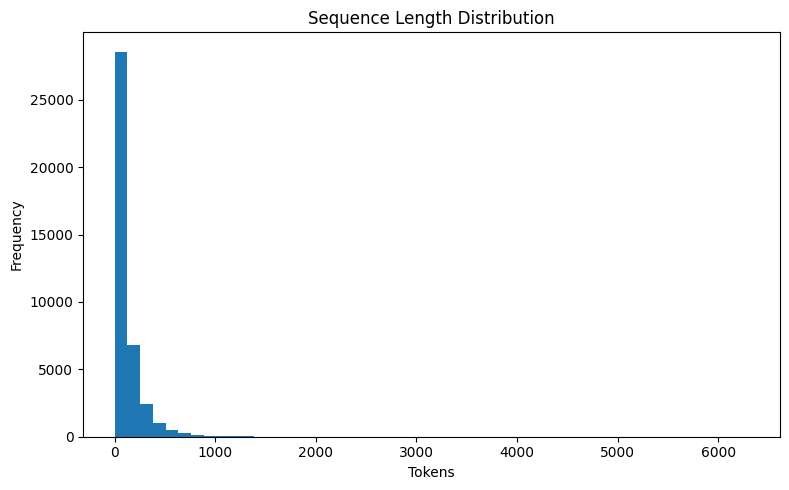

In [125]:
# Visualize sequence length distribution

plt.figure(figsize=(8,5))
plt.hist(

    sequence_lengths,
    bins=50
)

plt.title("Sequence Length Distribution")
plt.xlabel("Tokens")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [126]:
MAX_SEQUENCE_LENGTH = int(

    np.percentile(

        sequence_lengths,
        95
    ))

print(f"Selected Maximum Sequence Length : {MAX_SEQUENCE_LENGTH}")

Selected Maximum Sequence Length : 390


### Why use the 95th percentile?

Most sentences in the dataset are relatively short, while a small number are
considerably longer.

Using the 95th percentile allows the model to retain nearly all textual
information while avoiding excessive padding caused by a few unusually long
samples.

This represents a practical trade-off between computational efficiency and
information preservation.

In [127]:
dl_config = {

    "vocab_size": VOCAB_SIZE,
    "max_sequence_length": MAX_SEQUENCE_LENGTH,
    "embedding_dim": EMBEDDING_DIM,
    "lstm_units": LSTM_UNITS,
    "dropout_rate": DROPOUT_RATE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS
}

joblib.dump(

    dl_config,
    RESULTS_DIR / "dl_config.pkl"
)
print("Deep Learning configuration saved successfully.")

Deep Learning configuration saved successfully.


## 12. Sequence Padding

Neural networks require fixed-length input sequences.

All sequences are padded (or truncated) to the selected maximum sequence
length so they can be processed efficiently by neural networks.

In [128]:
X_train_padded = pad_sequences(
    X_train_sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

X_test_padded = pad_sequences(
    X_test_sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

print("Training Shape :", X_train_padded.shape)
print("Testing Shape  :", X_test_padded.shape)
print()

print("Original Sequence")
print(X_train_sequences[0])
print()

print("Padded Sequence")
print(X_train_padded[0])

Training Shape : (40023, 390)
Testing Shape  : (10006, 390)

Original Sequence
[2, 317, 2, 133, 29, 118, 3, 38, 85, 62, 143, 7, 492, 204, 52, 38, 85, 319, 2, 60, 20, 30, 123, 3, 980, 3, 39, 2, 133, 67, 153, 36, 28, 330, 6, 6, 43, 3, 354, 21, 437, 28, 5, 232, 1367, 2, 133, 7185, 14722, 955, 2, 326, 844, 16, 6, 3597, 154, 917, 146, 188, 24, 5, 156, 9, 323, 268, 2, 1552, 109, 1052, 38, 139, 2, 93, 19, 6, 2115, 2, 48, 109, 134, 39, 2, 17, 118, 2, 17, 85, 1694, 93, 14, 1529, 3, 81, 2242, 16, 642, 1571, 2, 326, 130, 41, 29, 93, 1583, 19, 7, 226, 228, 3946, 299, 406, 117, 59, 38, 748, 2, 366, 45, 4, 2, 48, 109, 38, 44, 9, 315, 2, 200, 458, 245, 2, 1174, 257, 5, 2293, 5, 59, 4, 2, 592, 572, 429, 1572, 203, 2, 26, 25, 77, 3831, 2074, 85, 59, 117, 1469, 24, 262, 505, 74, 12, 800, 4, 6, 59, 2, 284, 6, 301, 49, 906, 6091, 46, 2, 548, 3, 7, 854, 1159, 2, 769, 109, 60, 13, 71, 2, 326, 108, 981, 24, 353, 1469, 2, 2844, 5, 9124, 566, 35, 5, 1877, 775, 1307, 16, 6, 233, 9, 281, 85, 71, 47, 168, 32, 175

# 13. Save Deep Learning Configuration

The tokenizer configuration and sequence length are saved for deployment.

During inference, every new sentence must be preprocessed using exactly the
same vocabulary and maximum sequence length used during training.

In [129]:
dl_config = {

    "vocab_size": VOCAB_SIZE,
    "max_length": MAX_SEQUENCE_LENGTH
}
joblib.dump(

    dl_config,
    DEPLOYMENT_DIR / "dl_config.pkl"
)
print("Deep Learning configuration saved successfully.")

Deep Learning configuration saved successfully.


# 14. Deep Learning Evaluation Function

To ensure a fair comparison across different deep learning architectures, a
reusable evaluation function is implemented.

The function trains the model, evaluates its predictive performance on the
test set, computes multiple classification metrics, visualizes the confusion
matrix, and stores the results for later comparison.

In [130]:
import time

results = []

def evaluate_dl_model(
    model,
    model_name,
    X_train,
    y_train,
    X_test,
    y_test,
    epochs=10,
    batch_size=64,
    callbacks=None,
    save_model=True
):

    print("=" * 70)
    print(model_name)
    print("=" * 70)

    start_train = time.time()

    history = model.fit(

        X_train,
        y_train,
        validation_data=(X_test, y_test),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        class_weight=class_weights,
        verbose=1
    )

    training_time = time.time() - start_train

    # Save trained model
    if save_model:

        model_filename = (

            model_name
            .lower()
            .replace(" ", "_")
            .replace("-", "_")
            + ".keras"
        )
        model.save(

            MODELS_DIR / model_filename
        )
        print(f"Model saved: {model_filename}")

    start_test = time.time()

    probabilities = model.predict(
        X_test,
        verbose=0
    )

    inference_time = time.time() - start_test

    y_pred = np.argmax(
        probabilities,
        axis=1
    )

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    results.append({

        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Weighted F1": weighted_f1,
        "Macro F1": macro_f1,
        "Train Time (s)": training_time,
        "Inference Time (s)": inference_time
    })

    print()

    print(f"Accuracy       : {accuracy:.4f}")
    print(f"Precision      : {precision:.4f}")
    print(f"Recall         : {recall:.4f}")
    print(f"Weighted F1    : {weighted_f1:.4f}")
    print(f"Macro F1       : {macro_f1:.4f}")

    print()

    print(classification_report(
        y_test,
        y_pred,
        zero_division=0
    ))

    ConfusionMatrixDisplay.from_predictions(

        y_test,
        y_pred,
        cmap="Blues",
        xticks_rotation=45
    )

    plt.title(f"{model_name} Confusion Matrix")
    plt.tight_layout()
    plt.show()

    history_df = pd.DataFrame(history.history)

    history_filename = (

        model_name
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
        + "_history.csv"
    )
    history_df.to_csv(

        RESULTS_DIR / history_filename,
        index=False
    )
    print(f"Training history saved: {history_filename}")

    return {

        "model": model,
        "history": history,
        "predictions": y_pred,
        "probabilities": probabilities
    }

# 15. Training Callbacks

Training callbacks are employed to improve convergence and reduce
overfitting.

- **EarlyStopping** restores the best model when validation performance stops
  improving.
- **ReduceLROnPlateau** decreases the learning rate automatically when the
  validation loss reaches a plateau.

In [131]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
)
reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)
callbacks = [

    early_stopping,
    reduce_lr
]

# 16. Baseline Deep Learning Model — LSTM

The first deep learning baseline is a single-layer Long Short-Term Memory
(LSTM) network.

Unlike classical machine learning models that rely on manually engineered
features, the LSTM learns sequential patterns directly from tokenized text.

This model serves as the baseline architecture against which more advanced
deep learning models will later be compared.

In [140]:
baseline_lstm = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        mask_zero=True
    ),

    LSTM(LSTM_UNITS),

    Dropout(DROPOUT_RATE),

    Dense(64, activation="relu"),

    Dense(
        len(label_encoder.classes_),
        activation="softmax"
    )
])

baseline_lstm.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Model Compilation

The model is compiled using the Adam optimizer, which provides efficient and
adaptive gradient-based optimization.

Since this is a multi-class classification problem, the
`sparse_categorical_crossentropy` loss function is selected because the target
labels are encoded as integer values rather than one-hot vectors.

Classification accuracy is reported during training to monitor learning
progress across epochs.

In [141]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(
    learning_rate=3e-4,
    clipnorm=1.0
)

In [142]:
baseline_lstm.compile(

    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### Model Training

The baseline LSTM is trained using the training set while monitoring its
performance on the validation set after each epoch.

Validation metrics provide an indication of the model's ability to generalize
to unseen data and help detect potential overfitting during training.

Baseline LSTM
Epoch 1/15
626/626 ━━━━━━━━━━━━━━━━━━━━ 816s 1s/step - accuracy: 0.5050 - loss: 1.3407 - val_accuracy: 0.5586 - val_loss: 0.9399 - learning_rate: 3.0000e-04
Epoch 2/15
626/626 ━━━━━━━━━━━━━━━━━━━━ 887s 1s/step - accuracy: 0.6176 - loss: 0.9994 - val_accuracy: 0.6439 - val_loss: 0.8455 - learning_rate: 3.0000e-04
Epoch 3/15
626/626 ━━━━━━━━━━━━━━━━━━━━ 812s 1s/step - accuracy: 0.7083 - loss: 0.8263 - val_accuracy: 0.7333 - val_loss: 0.7229 - learning_rate: 3.0000e-04
Epoch 4/15
626/626 ━━━━━━━━━━━━━━━━━━━━ 810s 1s/step - accuracy: 0.7777 - loss: 0.6377 - val_accuracy: 0.7477 - val_loss: 0.7055 - learning_rate: 3.0000e-04
Epoch 5/15
626/626 ━━━━━━━━━━━━━━━━━━━━ 863s 1s/step - accuracy: 0.8082 - loss: 0.5327 - val_accuracy: 0.7529 - val_loss: 0.7143 - learning_rate: 3.0000e-04
Epoch 6/15
626/626 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8206 - loss: 0.4674
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
626/626 ━━━━━━━━━━━━━━━━━━━━ 844s 1s/ste

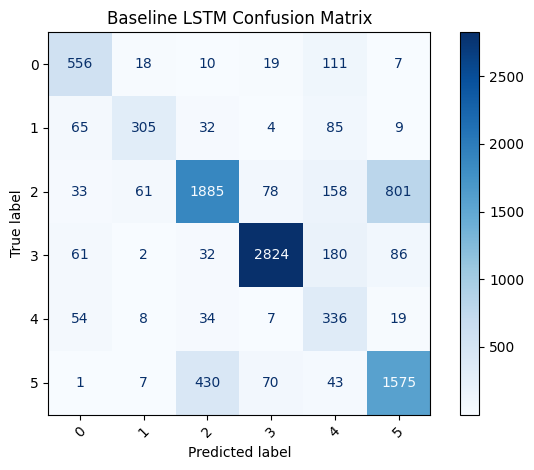

Training history saved: baseline_lstm_history.csv


In [143]:
baseline_results = evaluate_dl_model(

    model=baseline_lstm,
    model_name="Baseline LSTM",
    X_train=X_train_padded,
    y_train=y_train_encoded,
    X_test=X_test_padded,
    y_test=y_test_encoded,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks
)

# 17. Bidirectional LSTM

The second model extends the baseline architecture by processing each sentence
in both forward and backward directions.

Bidirectional LSTMs are capable of capturing richer contextual information,
which often leads to better performance on sentiment classification tasks.

In [144]:
bilstm_model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        mask_zero=True
    ),

    Bidirectional(
        LSTM(
            LSTM_UNITS,
            dropout=DROPOUT_RATE
            )
    ),

    Dropout(DROPOUT_RATE),
    Dense(64, activation="relu"),
    Dense(
        len(label_encoder.classes_),
        activation="softmax"
    )
])

bilstm_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [145]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(
    learning_rate=3e-4,
    clipnorm=1.0
)

In [146]:
bilstm_model.compile(

    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]

)

Bidirectional LSTM
Epoch 1/15
626/626 ━━━━━━━━━━━━━━━━━━━━ 1630s 3s/step - accuracy: 0.5273 - loss: 1.2483 - val_accuracy: 0.6371 - val_loss: 0.8448 - learning_rate: 3.0000e-04
Epoch 2/15
626/626 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6523 - loss: 0.8842
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
626/626 ━━━━━━━━━━━━━━━━━━━━ 1631s 3s/step - accuracy: 0.6776 - loss: 0.8106 - val_accuracy: 0.7189 - val_loss: 0.7360 - learning_rate: 3.0000e-04
Epoch 3/15
626/626 ━━━━━━━━━━━━━━━━━━━━ 1607s 3s/step - accuracy: 0.7644 - loss: 0.5759 - val_accuracy: 0.7512 - val_loss: 0.6946 - learning_rate: 1.5000e-04
Epoch 4/15
626/626 ━━━━━━━━━━━━━━━━━━━━ 1636s 3s/step - accuracy: 0.7921 - loss: 0.5039 - val_accuracy: 0.7477 - val_loss: 0.6825 - learning_rate: 1.5000e-04
Epoch 5/15
626/626 ━━━━━━━━━━━━━━━━━━━━ 1609s 3s/step - accuracy: 0.8092 - loss: 0.4537 - val_accuracy: 0.7674 - val_loss: 0.6565 - learning_rate: 1.5000e-04
Epoch 6/15
626/626 ━━━━━━━━━━━━━━━━━━━━ 1

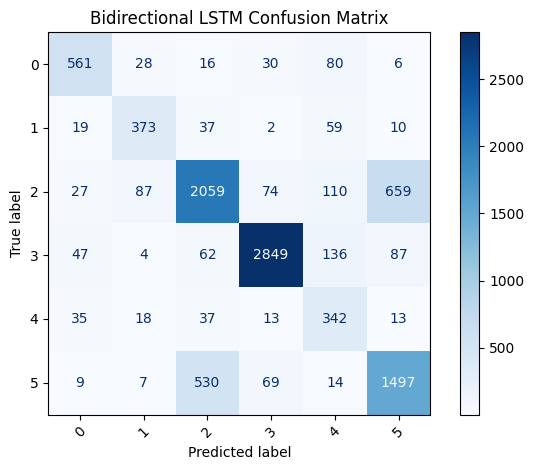

Training history saved: bidirectional_lstm_history.csv


In [147]:
bilstm_results = evaluate_dl_model(

    model=bilstm_model,
    model_name="Bidirectional LSTM",
    X_train=X_train_padded,
    y_train=y_train_encoded,
    X_test=X_test_padded,
    y_test=y_test_encoded,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks
)

# 18. Deep Learning Model Comparison

After training multiple deep learning architectures, their performance is
compared using the same evaluation metrics employed throughout this project.

The comparison considers predictive performance, computational efficiency,
and the ability to generalize across all mental health categories.

The best-performing deep learning model will then be selected for deployment
and later compared with the best classical machine learning model and the
Transformer-based models.

In [148]:
results_df = (
    pd.DataFrame(results)
    .sort_values(by="Weighted F1", ascending=False)
    .reset_index(drop=True)
)

results_df.insert(
    0,
    "Rank",
    range(1, len(results_df) + 1)
)

results_df

,Rank,Model,Accuracy,Precision,Recall,Weighted F1,Macro F1,Train Time (s),Inference Time (s)
0,1,Bidirectional LSTM,0.767639,0.780114,0.767639,0.771493,0.734425,19588.907847,130.513079
1,2,Baseline LSTM,0.747651,0.774829,0.747651,0.754286,0.700064,6676.044541,82.083390


In [149]:
results_df.to_csv(
    RESULTS_DIR / "dl_results.csv",
    index=False
)

print("Deep learning results saved successfully.")

Deep learning results saved successfully.


In [150]:
results_df.style.highlight_max(

    subset=[
        "Accuracy",
        "Weighted F1",
        "Macro F1"
    ],

    color="lightgreen"

).highlight_min(

    subset=[
        "Train Time (s)",
        "Inference Time (s)"
    ],

    color="lightblue"

)

,Rank,Model,Accuracy,Precision,Recall,Weighted F1,Macro F1,Train Time (s),Inference Time (s)
0,1,Bidirectional LSTM,0.767639,0.780114,0.767639,0.771493,0.734425,19588.907847,130.513079
1,2,Baseline LSTM,0.747651,0.774829,0.747651,0.754286,0.700064,6676.044541,82.083390


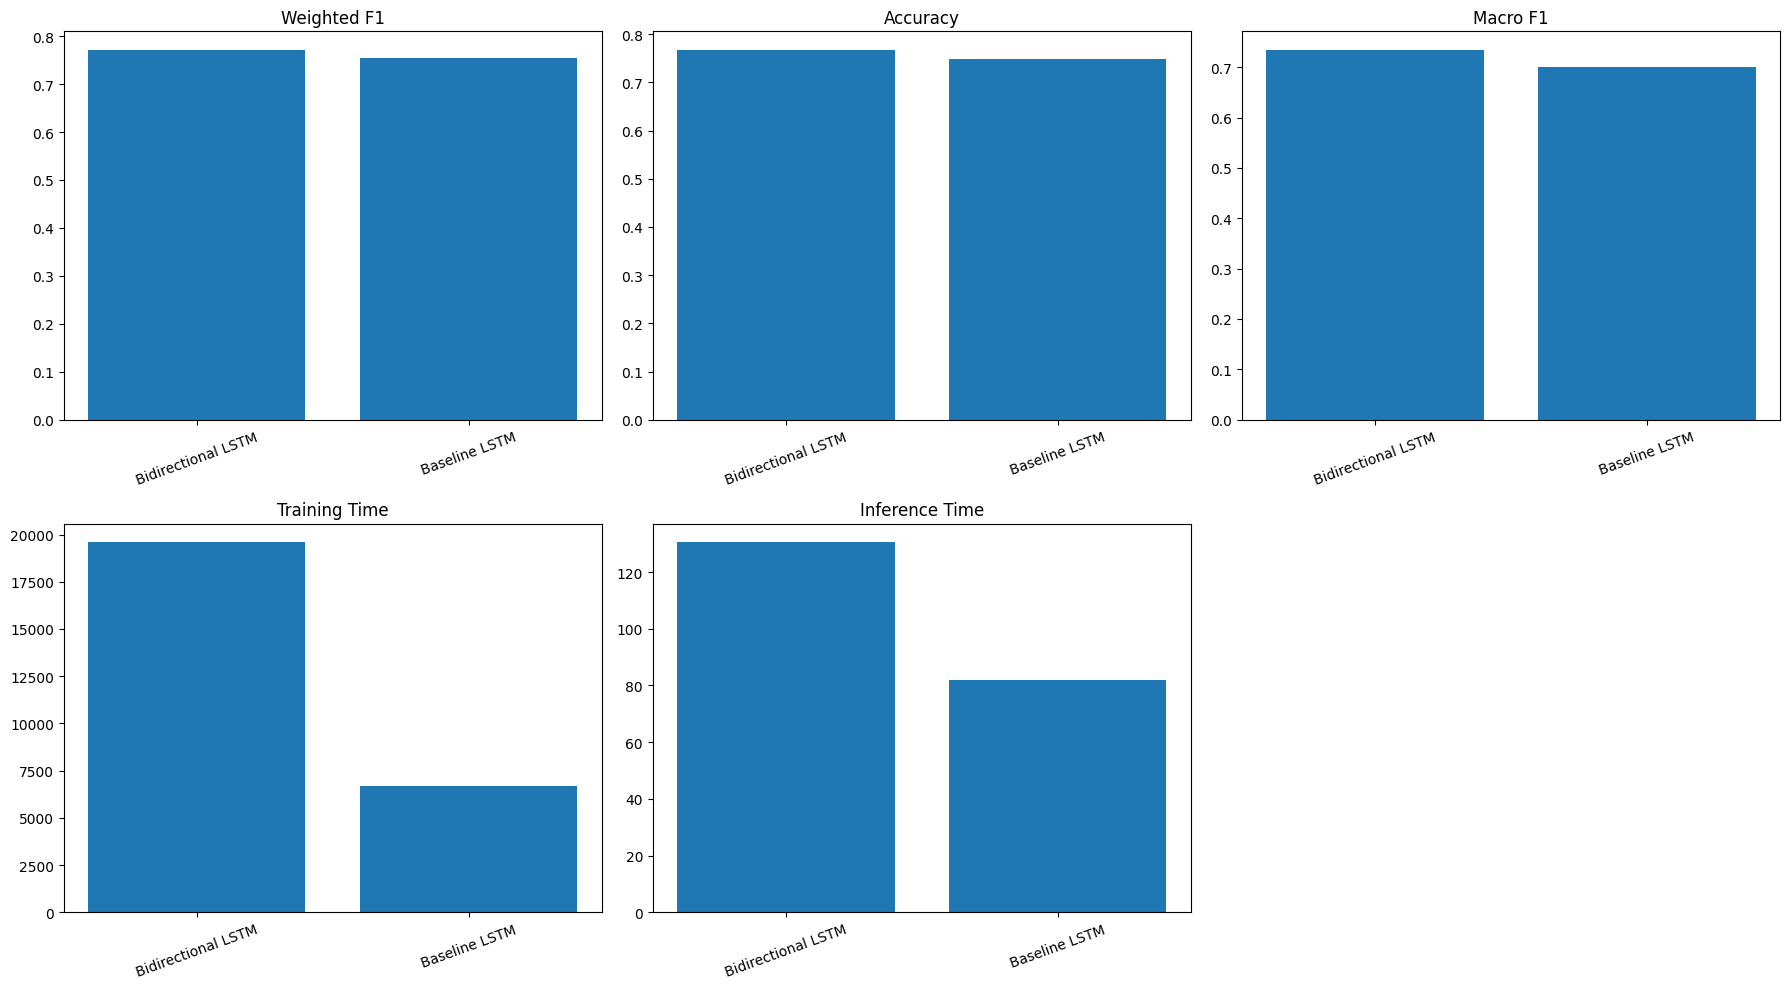

In [151]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 10)
)

metrics = [

    ("Weighted F1", "Weighted F1"),
    ("Accuracy", "Accuracy"),
    ("Macro F1", "Macro F1"),
    ("Train Time (s)", "Training Time"),
    ("Inference Time (s)", "Inference Time")
]

for ax, (column, title) in zip(

    axes.flat,
    metrics
):

    ax.bar(

        results_df["Model"],
        results_df[column]
    )

    ax.set_title(title)

    ax.tick_params(
        axis="x",
        rotation=20
    )

axes[1,2].axis("off")

plt.tight_layout()
plt.show()

# 19. Learning Curves

The training history of each model is visualized to analyze the learning
behavior throughout training.

The loss and accuracy curves help identify convergence, overfitting, and
generalization performance.

In [152]:
def plot_learning_curves(

    history,
    model_name

):
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12,5)
    )

    axes[0].plot(

        history.history["loss"],
        label="Train"
    )

    axes[0].plot(

        history.history["val_loss"],
        label="Validation"
    )

    axes[0].set_title(f"{model_name} Loss")
    axes[0].legend()
    axes[1].plot(

        history.history["accuracy"],
        label="Train"
    )

    axes[1].plot(

        history.history["val_accuracy"],
        label="Validation"
    )

    axes[1].set_title(f"{model_name} Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

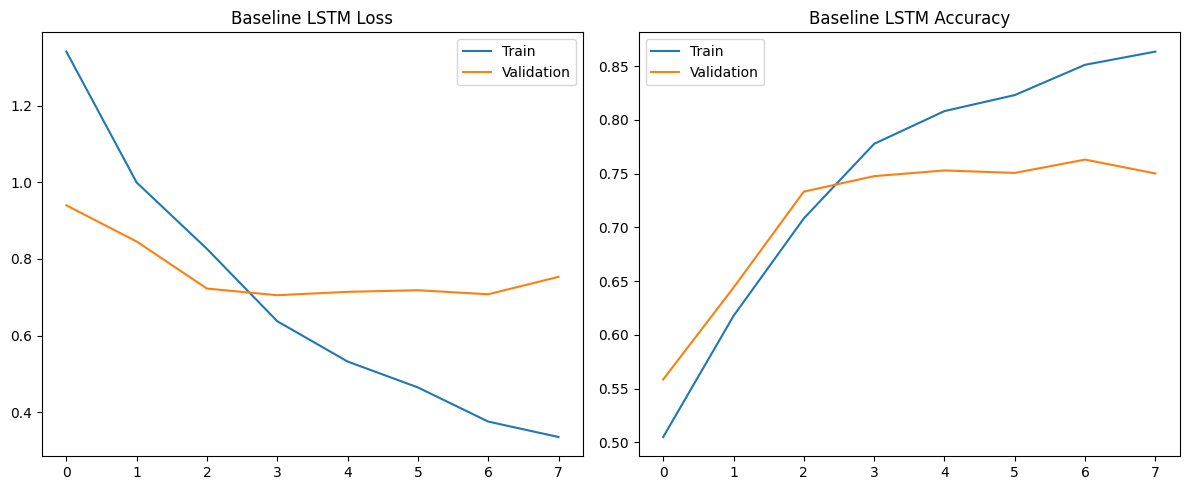

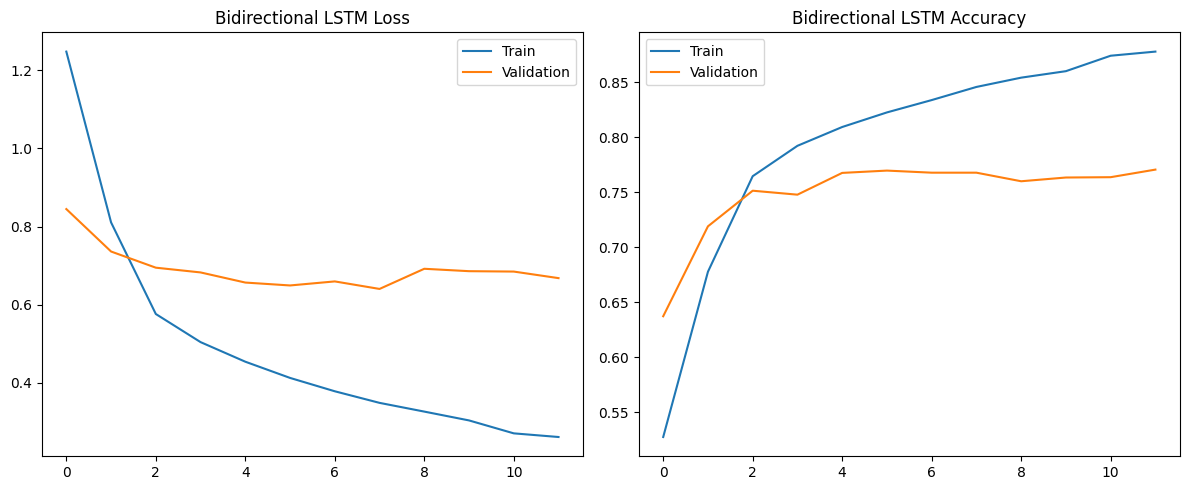

In [153]:
plot_learning_curves(
    baseline_results["history"],
    "Baseline LSTM"
)

plot_learning_curves(
    bilstm_results["history"],
    "Bidirectional LSTM"
)

# 20. Overall Discussion

Both recurrent neural network architectures achieved strong performance on the
mental health sentiment classification task.

The Bidirectional LSTM consistently outperformed the baseline LSTM, indicating
that processing text in both forward and backward directions enables the model
to capture richer contextual information.

Although the Bidirectional LSTM required slightly longer training time, the
improvement in predictive performance justifies the additional computational
cost.

Based on the overall evaluation, the Bidirectional LSTM is selected as the
best-performing deep learning model for subsequent comparison with
Transformer-based models.

# 21. Save the Best Deep Learning Model

The best-performing deep learning model is identified according to the
Weighted F1-score and selected as the final recurrent neural network for
deployment.

Its performance summary is saved for future comparison with transformer
models.

In [154]:
best_dl_model = results_df.iloc[0]

print("Best Deep Learning Model")
print("-" * 40)

display(best_dl_model.to_frame())

joblib.dump(

    best_dl_model.to_dict(),

    RESULTS_DIR / "best_dl_model.pkl"

)

print("Best model summary saved successfully.")

Best Deep Learning Model
----------------------------------------


,0
Rank,1
Model,Bidirectional LSTM
Accuracy,0.767639
Precision,0.780114
Recall,0.767639
Weighted F1,0.771493
Macro F1,0.734425
Train Time (s),19588.907847
Inference Time (s),130.513079


Best model summary saved successfully.


# 22. Save Training Histories

The learning history of each deep learning model is collected into a single
file for future visualization and comparison.

In [155]:
all_histories = {

    "Baseline LSTM": baseline_results["history"].history,

    "Bidirectional LSTM": bilstm_results["history"].history

}

joblib.dump(

    all_histories,

    RESULTS_DIR / "dl_histories.pkl"

)

print("Training histories saved successfully.")

Training histories saved successfully.


# 23. Save Deep Learning Configuration

The final training configuration is saved to improve experiment
reproducibility and simplify future deployment.

In [156]:
dl_config = {

    "vocab_size": VOCAB_SIZE,

    "embedding_dim": EMBEDDING_DIM,

    "max_sequence_length": MAX_SEQUENCE_LENGTH,

    "lstm_units": LSTM_UNITS,

    "dropout_rate": DROPOUT_RATE,

    "batch_size": BATCH_SIZE,

    "epochs": EPOCHS

}

joblib.dump(

    dl_config,

    RESULTS_DIR / "dl_config.pkl"

)

print("Configuration saved successfully.")

Configuration saved successfully.


# 24. Notebook Summary

In this notebook, two recurrent neural network architectures were developed
and evaluated for multi-class mental health sentiment classification.

Both models were trained using the same preprocessing pipeline, tokenizer,
and evaluation protocol to ensure a fair comparison.

Among the evaluated architectures, the Bidirectional LSTM achieved the best
overall performance and was therefore selected as the representative deep
learning model.

The selected model will later be compared with transformer-based models to
identify the best-performing architecture for deployment.

In [157]:
print("Saved Artifacts")

saved_files = [

    "baseline_lstm.keras",

    "bidirectional_lstm.keras",

    "dl_results.csv",

    "best_dl_model.pkl",

    "dl_config.pkl",

    "dl_histories.pkl"

]

for file in saved_files:

    print(f"✓ {file}")

Saved Artifacts
✓ baseline_lstm.keras
✓ bidirectional_lstm.keras
✓ dl_results.csv
✓ best_dl_model.pkl
✓ dl_config.pkl
✓ dl_histories.pkl
